# Computational Linear Algebra: Singular Value Decomposition Homework

## Initialization:
Fill the missing values in this text box and in the following code-cell.

**Academic Year:** 2024/2025

### Team Members (Alphabetical Order):
1. Aljosevic, Ismail (337769);
2. Amato, Daniele (334211).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
from PIL import Image

**Uploading an RGB image**

Saving cat_img.jpg to cat_img.jpg


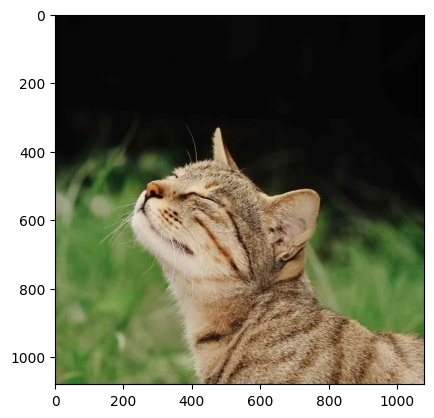

In [2]:
img = files.upload()
name = next(iter(img))
img = Image.open(name).convert("RGB")
plt.imshow(img)

**Converting it into an array**

In [3]:
img_array = np.array(img) / 255.0
img_array.shape

(1080, 1080, 3)

**Performing Singular Value Decomposition**

In [4]:
# SVD
U = {}
S = {}
V = {}
singular_values = {}

for c in range(3):
  channel = img_array[:, :, c]
  U[c], s, V[c] = np.linalg.svd(channel, full_matrices=False)
  singular_values[c] = s
  S[c] = np.diag(s)

**Plotting the first 50 singular values**

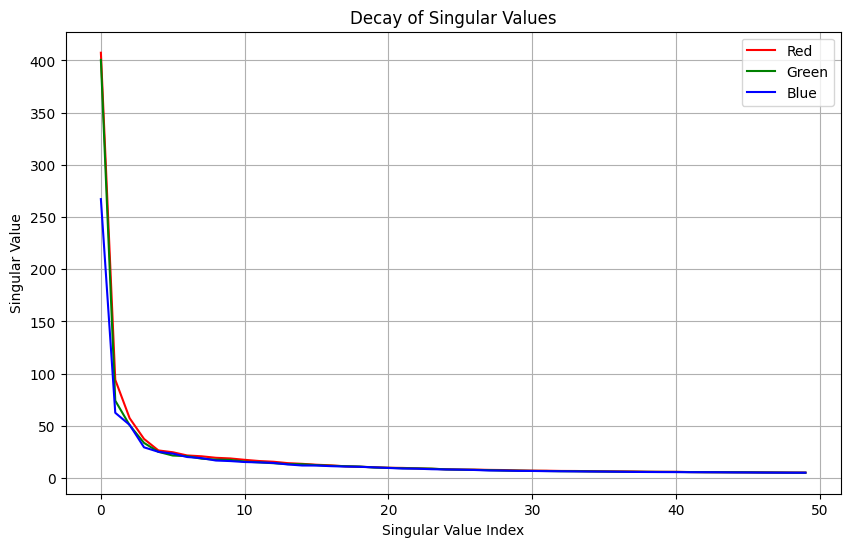

In [5]:
colors = ['Red', 'Green', 'Blue']
plt.figure(figsize=(10, 6))
for c in range(3):
  plt.plot(singular_values[c][:50], label=colors[c], color=colors[c])
plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")
plt.title("Decay of Singular Values")
plt.grid(True)
plt.legend()
plt.savefig("First50SV.png", dpi=300, bbox_inches='tight')
plt.show()

We see a peak in the first 3-5 singular values, so we can expect them to contain the majority of signal's energy. Let's plot the cumulative energy of the signal with increasing number of signal values k, for each of the 3 channels.

In [6]:
energy_ratios = []

for c in range(3):
  sigma = singular_values[c]
  total_energy = np.sum(sigma**2)
  energy_k = np.cumsum(sigma**2) / total_energy
  energy_ratios.append(energy_k)

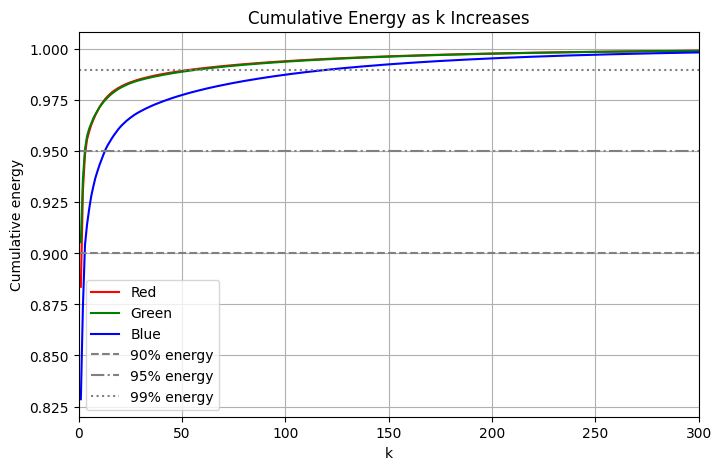

In [7]:
colors = ['Red', 'Green', 'Blue']
plt.figure(figsize=(8, 5))
for c in range(3):
  plt.plot(range(1, len(energy_ratios[c]) + 1), energy_ratios[c], label=colors[c], color=colors[c].lower())
plt.axhline(0.9, color='gray', linestyle='--', label='90% energy')
plt.axhline(0.95, color='gray', linestyle='-.', label='95% energy')
plt.axhline(0.99, color='gray', linestyle=':', label='99% energy')
plt.xlim(0, 300)  # taglia l'asse x per vedere meglio
plt.xlabel("k")
plt.ylabel("Cumulative energy")
plt.title("Cumulative Energy as k Increases")
plt.grid(True)
plt.legend()
plt.savefig("CumEnergy.png", dpi=300, bbox_inches='tight')
plt.show()

In [8]:
k_90 = [np.argmax(e >= 0.90) + 1 for e in energy_ratios]  # indexes start from 0 so +1
k_95 = [np.argmax(e >= 0.95) + 1 for e in energy_ratios]
k_99 = [np.argmax(e >= 0.99) + 1 for e in energy_ratios]
print(k_90)
print(k_95)
print(k_99)

[np.int64(2), np.int64(1), np.int64(3)]
[np.int64(4), np.int64(3), np.int64(13)]
[np.int64(55), np.int64(58), np.int64(121)]


As expected, the vast majority of signal's energy is expressed by the first few singular values. The first 2 channels (red and green) share almost the same trend, while the third one (blue) needs a higher number k of singular values to express the same amount of energy.

In [9]:
def img_compression(k, img, U, S, V):
  plt.figure(figsize=(15, 5))
  comp_img = np.zeros_like(img)
  for c in range(3):
    U_k = U[c][:, :k]
    S_k = S[c][:k, :k]
    V_k = V[c][:k, :]
    comp_img[:, :, c] = U_k @ S_k @ V_k
  comp_img = np.clip(comp_img, 0, 1)
  plt.imshow(comp_img)
  plt.title(f"k = {k}")
  plt.axis('off')
  filename = f"compressed_k{k}.png"
  plt.savefig(filename, dpi=300, bbox_inches='tight')
  plt.show()
  return comp_img

**Plotting the compressed image**

Let's start with a low number of singular values. For example, since the 95% of the total signal energy is contained in the first 13 singular values, we will try with k = 15.

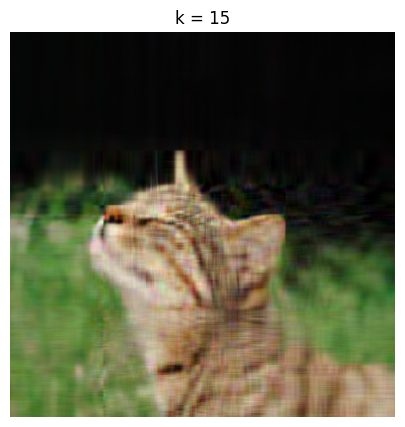

In [10]:
k = 15
comp_img = img_compression(k, img_array, U, S, V)

The image is recognizable, but it's very blurry. So, 95% of expressed energy is not enough. The 99% is reached with k = 121, we will round it to 120.

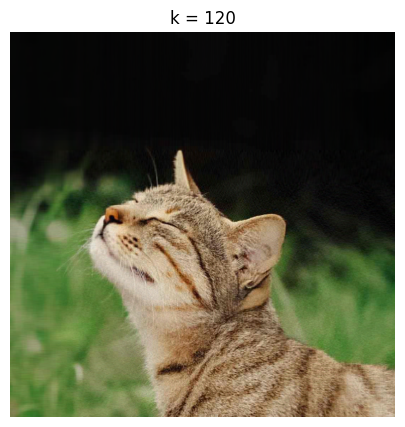

In [11]:
k = 120
comp_img = img_compression(k,img_array,U,S,V)

Now the image looks very clear, so we can infer that 99% is a good amount of energy to recreate a clean picture.

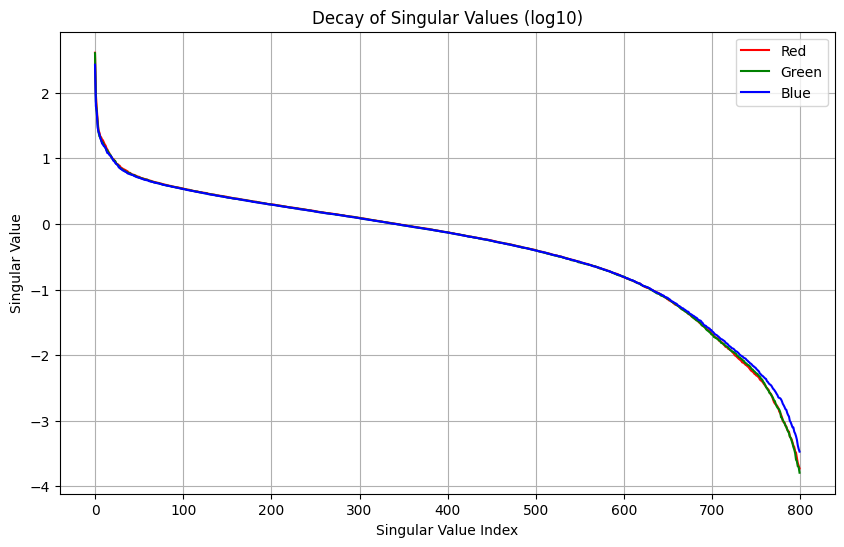

In [12]:
colors = ['Red', 'Green', 'Blue']
plt.figure(figsize=(10, 6))
for c in range(3):
    plt.plot(np.log10(singular_values[c][:800]), label=colors[c], color=colors[c])
plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")
plt.title("Decay of Singular Values (log10)")
plt.grid(True)
plt.legend()
plt.savefig("SVlog10.png", dpi=300, bbox_inches='tight')
plt.show()

For confirmation, we can look at the singular values in logarithmic scale: after the first peak, they slowly decrease until around 500-600, when the decay becomes more and more steeper. We can imagine that with those values of k the image looks pretty much the same as the original.

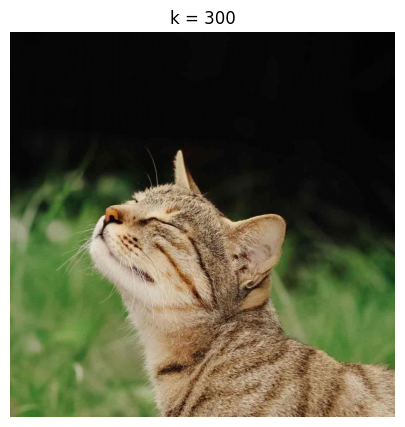

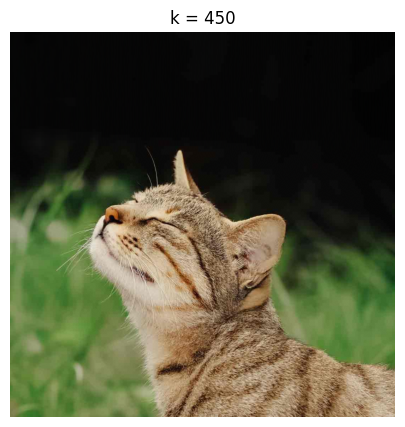

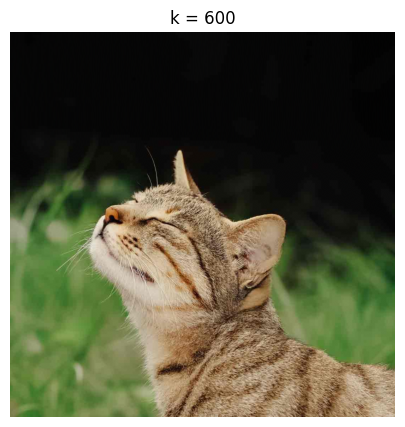

In [13]:
for k in [300, 450, 600]:
  img_compression(k,img_array,U,S,V)